In [36]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import os
from ydata_profiling import ProfileReport
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency 

### Read Data

In [53]:
BASE_PATH = os.path.abspath('..\data')
df = pd.read_csv(os.path.join(BASE_PATH, 'silver', 'joined_purchases.csv'))
df.head()

,date,company_id,productcategory,quantity,revenue,unemployment_rate,gdp_value,cpi,mortgage_rate_30y,company_name,location,company_type,employees
0,2020-01-31 00:00:10,7.0,Toys & Games,45.0,1707.94,3.5,21481.367,257.971,3.51,Ryan PLC,Lake Nicole,private,1-10
1,2020-01-31 00:36:08,7.0,Smart Home,71.0,1510.22,3.5,21481.367,257.971,3.51,Ryan PLC,Lake Nicole,private,1-10
2,2020-01-31 00:52:35,3.0,Gaming,58.0,1006.68,3.5,21481.367,257.971,3.51,"Smith, Weber and Spence",Francisborough,non-profit,101-500
3,2020-01-31 00:57:11,3.0,Wearable Tech,46.0,1840.69,3.5,21481.367,257.971,3.51,"Smith, Weber and Spence",Francisborough,non-profit,101-500
4,2020-01-31 00:58:07,8.0,Fitness & Health,45.0,2130.24,3.5,21481.367,257.971,3.51,"Jackson, Cabrera and Morales",Barnettfort,private,51-100


### Explore Data with Pandas Profiling

In [7]:
profile = ProfileReport(df, title='Purchasing Analysis')
profile.to_file(
    os.path.join(BASE_PATH, 'silver', 'purchase_analysis.html')
)

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 63.83it/s]


### Remove ID's and names

In [54]:
# We also remove here the revenue since it can be deduced directly from quantity

df.drop(
    ['company_id', 'company_name', 'revenue'], 
    axis=1,
    inplace=True
)

df.drop_duplicates(
    inplace=True
)


df.head()

,date,productcategory,quantity,unemployment_rate,gdp_value,cpi,mortgage_rate_30y,location,company_type,employees
0,2020-01-31 00:00:10,Toys & Games,45.0,3.5,21481.367,257.971,3.51,Lake Nicole,private,1-10
1,2020-01-31 00:36:08,Smart Home,71.0,3.5,21481.367,257.971,3.51,Lake Nicole,private,1-10
2,2020-01-31 00:52:35,Gaming,58.0,3.5,21481.367,257.971,3.51,Francisborough,non-profit,101-500
3,2020-01-31 00:57:11,Wearable Tech,46.0,3.5,21481.367,257.971,3.51,Francisborough,non-profit,101-500
4,2020-01-31 00:58:07,Fitness & Health,45.0,3.5,21481.367,257.971,3.51,Barnettfort,private,51-100


### Check correlations

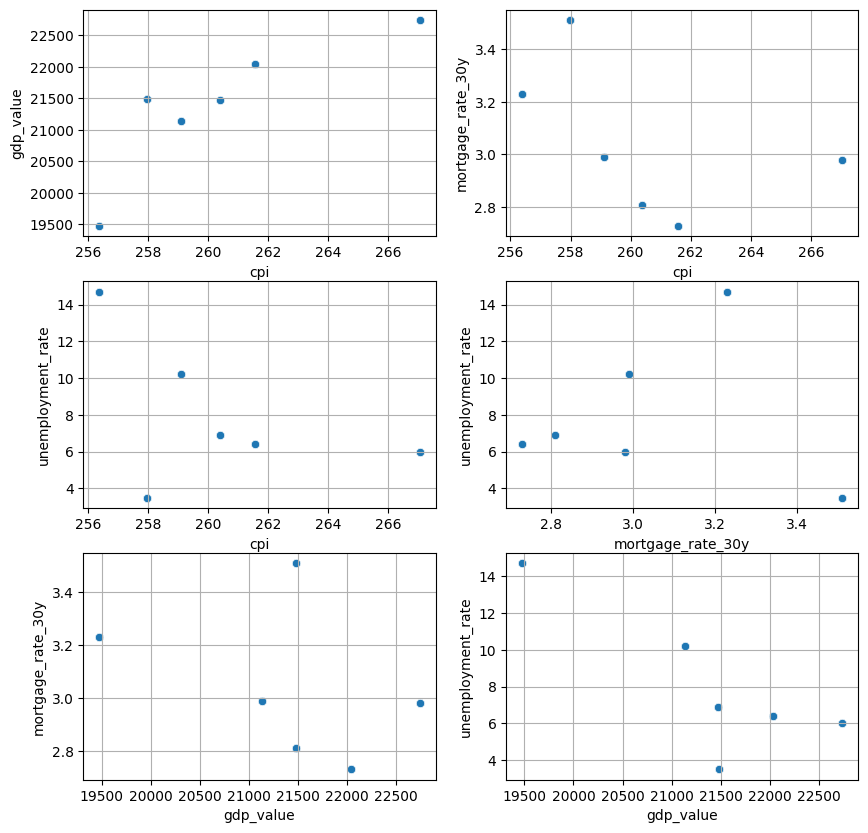

In [55]:
## Correlations between economic variables

fig, axes = plt.subplots(3, 2, figsize=(10, 10))
axes = axes.ravel()

sns.scatterplot(
    data=df,
    x='cpi',
    y='gdp_value',
    ax=axes[0]
)

sns.scatterplot(
    data=df,
    x='cpi',
    y='mortgage_rate_30y',
    ax=axes[1]
)

sns.scatterplot(
    data=df,
    x='cpi',
    y='unemployment_rate',
    ax=axes[2]
)

sns.scatterplot(
    data=df,
    x='mortgage_rate_30y',
    y='unemployment_rate',
    ax=axes[3]
)

sns.scatterplot(
    data=df,
    x='gdp_value',
    y='mortgage_rate_30y',
    ax=axes[4]
)

sns.scatterplot(
    data=df,
    x='gdp_value',
    y='unemployment_rate',
    ax=axes[5]
)

for i in range(6):
    axes[i].grid()


plt.show()

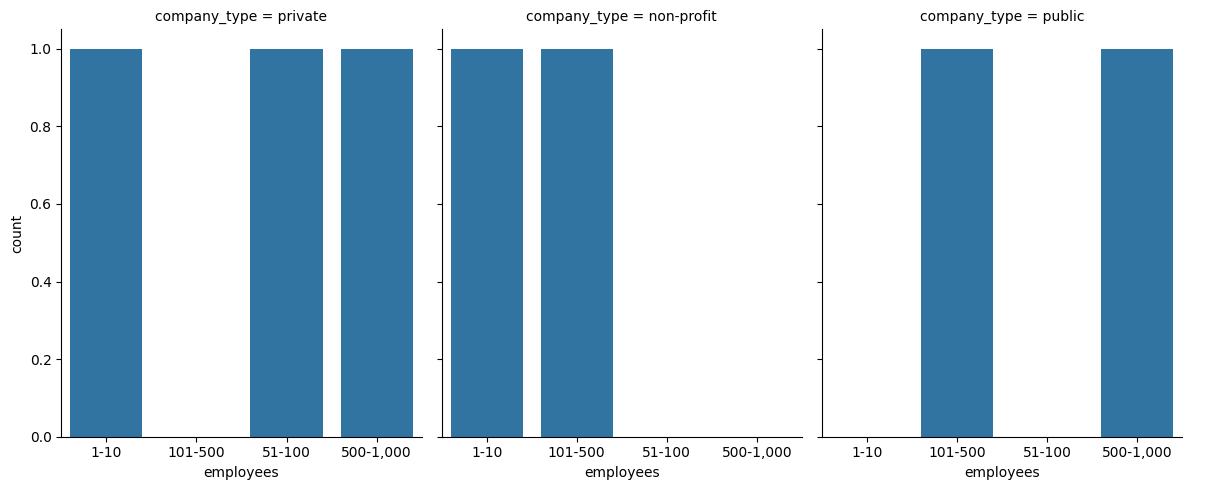

In [56]:
## Correlations between categorical variables
df_comp = df[['company_type', 'employees']].drop_duplicates()

sns.catplot(
    data = df_comp,
    kind = 'count',
    x = 'employees',
    col = 'company_type',
    aspect = .8
)

In [57]:
# Chi-square test to check whether there is a relationship between size and type of the company
# Actually, there is not enough observations here to really make the test.

contingency_table = pd.crosstab(df_comp['company_type'], df_comp['employees'])
chi2, p_val, dof, expected = chi2_contingency(contingency_table)


print("--- Contingency Table ---")
print(contingency_table)
print("\n" + "="*30 + "\n")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"p-value: {p_val:.4f}")
print(f"Degrees of Freedom: {dof}")
print("\nExpected Frequencies Table:")
print(expected)
print("\n" + "="*30 + "\n")

--- Contingency Table ---
employees     1-10  101-500  500-1,000  51-100
company_type                                  
non-profit       1        1          0       0
private          1        0          1       1
public           0        1          1       0


Chi-Square Statistic: 4.6667
p-value: 0.5872
Degrees of Freedom: 6

Expected Frequencies Table:
[[0.57142857 0.57142857 0.57142857 0.28571429]
 [0.85714286 0.85714286 0.85714286 0.42857143]
 [0.57142857 0.57142857 0.57142857 0.28571429]]




### Analyze Outliers

<Axes: ylabel='quantity'>

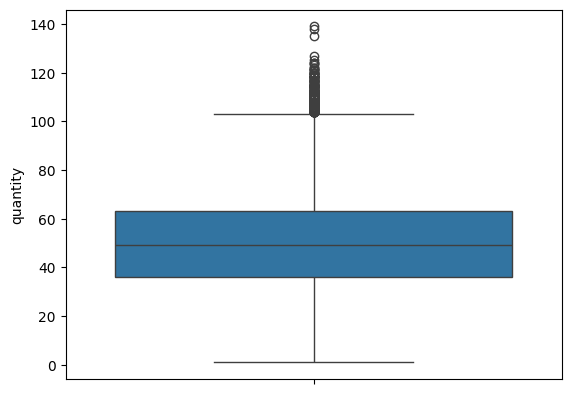

In [58]:
sns.boxplot(
    data = df,
    y = 'quantity'
)

In [59]:
# What are those outliers? What is the percentage of outlier ?

x = np.quantile(df['quantity'], [0, 0.25, 0.5, 0.75, 1])

q1 = x[1]
median = x[2]
q3 = x[3]
iqr = q3 -  q1

df['outlier'] = np.where(
    (df['quantity'] > q3 + 1.5*iqr) |
    (df['quantity'] < q1 - 1.5*iqr),
    1, 0
) 

outliers = df[df['outlier'] == 1]['date'].count()
rows = df['date'].count()

print(f'{outliers} Outliers found --> {outliers/rows * 100} % of total data')

df[df['outlier'] == 1].head(10)

332 Outliers found --> 0.332 % of total data


,date,productcategory,quantity,unemployment_rate,gdp_value,cpi,mortgage_rate_30y,location,company_type,employees,outlier
491,2020-02-02 19:15:36,Smart Home,105.0,3.5,21481.367,257.971,3.51,Barnettfort,private,51-100,1
678,2020-02-03 19:18:31,Books & E-readers,105.0,3.5,21481.367,257.971,3.51,Barnettfort,private,51-100,1
1002,2020-02-05 13:00:36,Security & Surveillance,107.0,3.5,21481.367,257.971,3.51,Vaughnbury,private,1-10,1
1288,2020-02-07 00:49:58,Security & Surveillance,110.0,3.5,21481.367,257.971,3.51,New Gloriamouth,private,"500-1,000",1
1363,2020-02-07 09:48:23,Security & Surveillance,107.0,3.5,21481.367,257.971,3.51,Lake Nicole,private,1-10,1
1424,2020-02-07 17:28:01,Cookware,106.0,3.5,21481.367,257.971,3.51,East Theresaview,private,51-100,1
1599,2020-02-08 16:44:04,Wearable Tech,111.0,3.5,21481.367,257.971,3.51,Douglastown,public,"500-1,000",1
1915,2020-02-10 13:41:09,Gaming,104.0,3.5,21481.367,257.971,3.51,Barnettfort,private,51-100,1
2014,2020-02-11 01:18:01,Books & E-readers,106.0,3.5,21481.367,257.971,3.51,East Theresaview,private,51-100,1
2238,2020-02-12 05:38:08,Footwear,105.0,3.5,21481.367,257.971,3.51,New Gloriamouth,private,"500-1,000",1


<Axes: ylabel='quantity'>

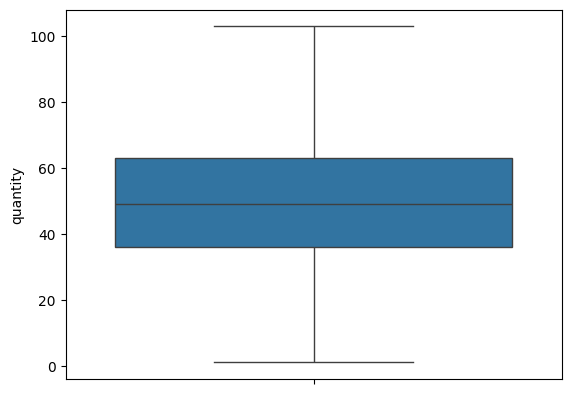

In [60]:

df = df[df['outlier'] == 0].drop('outlier', axis=1)
sns.boxplot(
    data = df,
    y = 'quantity'
)

### Analyze Autocorrelations

<Axes: xlabel='date'>

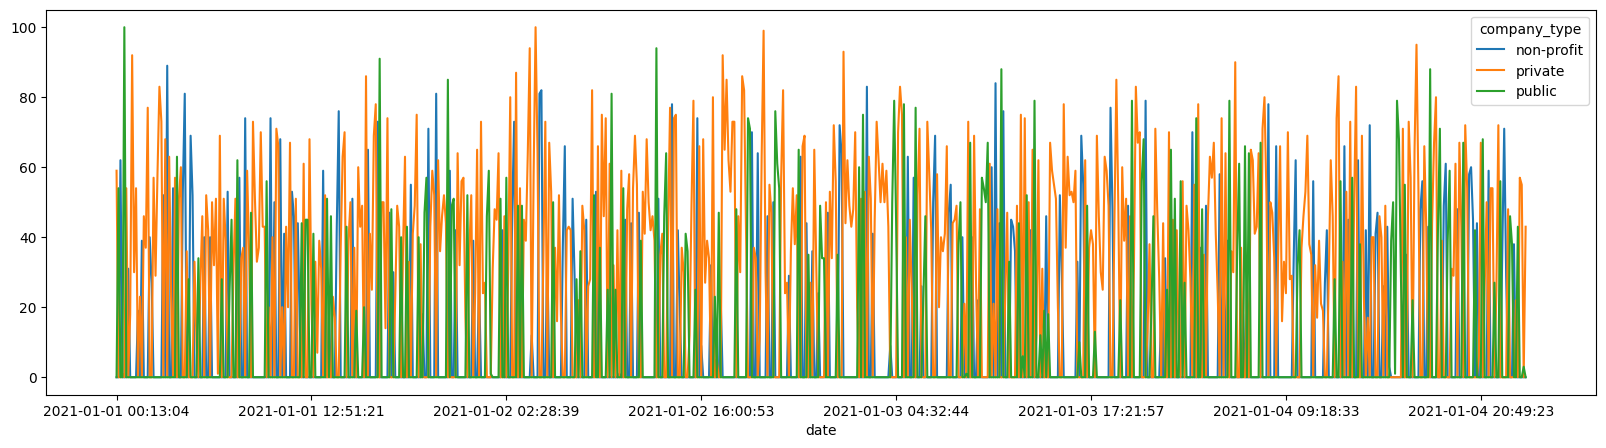

In [61]:
df_quantity = df.pivot_table(
    index = 'date',
    columns = 'company_type',
    values = 'quantity'
).fillna(0)

df_quantity['2021-01-01':'2021-01-05'].plot(figsize=(20, 5))

In [62]:
df_q = df.set_index('date')

df_q.head()

,productcategory,quantity,unemployment_rate,gdp_value,cpi,mortgage_rate_30y,location,company_type,employees
date,,,,,,,,,
2020-01-31 00:00:10,Toys & Games,45.0,3.5,21481.367,257.971,3.51,Lake Nicole,private,1-10
2020-01-31 00:36:08,Smart Home,71.0,3.5,21481.367,257.971,3.51,Lake Nicole,private,1-10
2020-01-31 00:52:35,Gaming,58.0,3.5,21481.367,257.971,3.51,Francisborough,non-profit,101-500
2020-01-31 00:57:11,Wearable Tech,46.0,3.5,21481.367,257.971,3.51,Francisborough,non-profit,101-500
2020-01-31 00:58:07,Fitness & Health,45.0,3.5,21481.367,257.971,3.51,Barnettfort,private,51-100
